# Import statements

In [1]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")


from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math

import matplotlib.pyplot as plt

import os

import numpy as np

import itertools

import seaborn as sns


In [2]:
# get the working directory
os.getcwd()

'/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20251105_Arul_Tuning_Redo'

In [3]:
INPUT_DIR = os.path.join(os.getcwd(), "inputs")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")

# create the output directory if it does not exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)

In [4]:
sa_correct = {"6-well": 1,
              "24-well":0.2,
              "48-well": 0.088,
              "96-well": 0.32/9.6,}



materials_df = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20250915_TI_pilot_planning/inputs/material_definitions.csv")

size_dict = materials_df.set_index("material")["size_bp"].to_dict()

mw_dict = dict([(mid, size_dict[mid] * 0.650 / 1000) for mid in size_dict])  # in ng/fmol

In [5]:
size_dict

{'m567_GvpA': 4580,
 'm163_GvpF': 5108,
 'm164_GvpG': 4749,
 'm165_GvpJ': 5117,
 'm166_GvpK': 4838,
 'm167_GvpN': 5378,
 'm168_GvpV': 4723,
 'm169_GvpW': 5051,
 'puc19': 2686}

In [6]:
mw_dict

{'m567_GvpA': 2.977,
 'm163_GvpF': 3.3202000000000003,
 'm164_GvpG': 3.08685,
 'm165_GvpJ': 3.3260500000000004,
 'm166_GvpK': 3.1447000000000003,
 'm167_GvpN': 3.4957000000000003,
 'm168_GvpV': 3.0699500000000004,
 'm169_GvpW': 3.28315,
 'puc19': 1.7459}

In [7]:
# estimating input concentrations for wells
fmol_1x = 50

# --- Choose starting concentrations ---
low_fmol = 0.125 * fmol_1x * 200/3000  # smallest ratio * fmol_basis * SA scaling
input_concentrations = {}
for key in mw_dict:
    low_fmol_conc = np.round(low_fmol * mw_dict[key] / 0.025, 2)  # ng/uL
    if key == "puc19":
        input_concentrations[key] = 100  # fixed at 100 ng/uL
    elif "gvpa" in key.lower():
        input_concentrations[key] = 100  # GvpA fixed at 100 ng/uL
    else:
        input_concentrations[key] = low_fmol_conc

input_concentrations 

{'m567_GvpA': 100,
 'm163_GvpF': np.float64(55.34),
 'm164_GvpG': np.float64(51.45),
 'm165_GvpJ': np.float64(55.43),
 'm166_GvpK': np.float64(52.41),
 'm167_GvpN': np.float64(58.26),
 'm168_GvpV': np.float64(51.17),
 'm169_GvpW': np.float64(54.72),
 'puc19': 100}

# Read in 384-well plate map

In [8]:
source_plate_map = os.path.join(os.getcwd(), "inputs", "384w_echo_input_plate_110525_Arul.csv")
source_map_names = pd.read_csv(source_plate_map, nrows=16, index_col=0, usecols=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])
source_map_conc = pd.read_csv(source_plate_map, skiprows=20, nrows=16, index_col=0, usecols=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])

# give me a dataframe with well, material, concentration for wells that are not empty
source_map_names = source_map_names.stack(dropna=False).reset_index()
source_map_names.columns = ["row", "col", "Name"]
source_map_names["Location"] = source_map_names["row"].astype(str) + source_map_names["col"].astype(str)

source_map_conc = source_map_conc.stack(dropna=False).reset_index()
source_map_conc.columns = ["row", "col", "Concentration"]
source_map_conc["Location"] = source_map_conc["row"].astype(str) + source_map_conc["col"].astype(str)

source_plate_df = pd.merge(source_map_names, source_map_conc[["Location", "Concentration"]], on="Location", how="left")
# if the name is null, make it water containing well
source_plate_df["Name"] = source_plate_df["Name"].fillna("water")
source_plate_df["Concentration"] = source_plate_df["Concentration"].fillna(1)
source_plate_df["Length"] = 0
source_plate_df["Units"] = "x"


for idx, row in source_plate_df.iterrows():
    material = row["Name"]
    for key in input_concentrations:
        if key.lower() in material.lower():
            # convert concentration from ng/uL to nM
            source_plate_df.at[idx, "Concentration"] = np.round(source_plate_df.at[idx, "Concentration"] / mw_dict[key],2)
            source_plate_df.at[idx, "Units"] = "nM"

            continue

source_plate_df[["Location", "Name", "Concentration", "Length", "Units"]].to_csv(os.path.join(INPUT_DIR, "384w_echo_input_plate_110525_Arul_conc.csv"), index=False)

/tmp/ipykernel_1030118/2006260589.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  source_map_names = source_map_names.stack(dropna=False).reset_index()
/tmp/ipykernel_1030118/2006260589.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  source_map_conc = source_map_conc.stack(dropna=False).reset_index()


In [9]:
source_plate_df.groupby(["Name", "Concentration"]).size().reset_index().rename(columns={0: "Count"})

,Name,Concentration,Count
0,m163_GvpF_50fmol,16.32,5
1,m164_GvpG_50fmol,17.43,5
2,m165_GvpJ_50fmol,16.27,5
3,m166_GvpK_50fmol,17.08,5
4,m167_GvpN_50fmol,15.33,5
5,m168_GvpV_50fmol,17.88,5
6,m169_GvpW_50fmol,16.23,5
7,m567_GvpA,35.47,46
8,puc19,59.05,16
9,water,1.00,287


In [10]:
source_plate_concentrations_dict = dict(zip(source_plate_df["Name"], source_plate_df["Concentration"]))

In [11]:
source_plate_concentrations_dict

{'water': 1.0,
 'm567_GvpA': 35.47,
 'm163_GvpF_50fmol': 16.32,
 'm164_GvpG_50fmol': 17.43,
 'm165_GvpJ_50fmol': 16.27,
 'm166_GvpK_50fmol': 17.08,
 'm167_GvpN_50fmol': 15.33,
 'm168_GvpV_50fmol': 17.88,
 'm169_GvpW_50fmol': 16.23,
 'puc19': 59.05}

# Clear source plate


In [12]:
import pandas as pd

df = pd.read_csv(os.path.join(INPUT_DIR, "source_plate.dat"), delimiter=',', header=None)
df = df.iloc[0:0]
df.to_csv(os.path.join(INPUT_DIR, "source_plate.dat"), index=False, header=False)

# Output Spreadsheet

In [13]:
#relevent input and output files

stock_file = os.path.join(INPUT_DIR, "384w_echo_input_plate_110525_Arul_conc.csv")
assoc_pre_file = os.path.join(INPUT_DIR, "all_picks_1x_association.csv")
assoc_name = os.path.join(os.path.join(OUTPUT_DIR, "20251105_ID_Arul_50fmol.csv"))
plate_file  = os.path.join(INPUT_DIR, "source_plate.dat") 

In [14]:
# make the materials in the experiment known
stocks_df = pd.read_csv(stock_file)
source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_Plus_AQ_BP', SPname="384_source_c1", reuse_wells=True)

# iterate over the stock file rows and create materials. Then add those materials to a well in the source plate instance.
for index, row in stocks_df.iterrows():
   source_well_plate.add_material_to_well(well=row.Location, material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units), volume=31000)

# create the EchoRun experiment with our source plate instance.
assoc_echo_calculator = mt_echo.EchoRun(DPtype= "Axygen 384", plate=source_well_plate)


# make the materials in the experiment known
for idx, row in stocks_df.drop_duplicates(subset=["Name"], keep="first").iterrows():
   assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))


10000


In [15]:
vol_basis = 4
assoc_echo_calculator.rxn_vol = vol_basis *1000 # PCR is large-volume!

# Define which column of the source file is what
name_col  = 1
conc_col  = 2
len_col   = 3
well_col  = 0
plate_col = 4

In [16]:
# Build a protocol, based on the association file.
assoc_echo_calculator.build_picklist_from_association_spreadsheet(input_filename= assoc_pre_file,
                                                                  well_column= 0,
                                                                  fill_with_water = True,
                                                                  water_name = "water"
                                                                  )


In [17]:
# Write the picklist
assoc_echo_calculator.write_picklist(assoc_name)

/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m167_GvpN_50fmol into well I23; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m165_GvpJ_50fmol into well I23; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material m166_GvpK_50fmol into well I23; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requestin

# Checker

In [18]:
import pandas as pd

final_association = pd.read_csv(assoc_pre_file)
output_association = pd.read_csv(f"{assoc_name}_EchoInput.csv")


display(final_association.head())
display(output_association.head())

volume_final = vol_basis * 1000 # in nL

,well_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
0,A1,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,1.666667,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,6.101915
1,A3,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.833333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.770210
2,A5,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.833333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.749501
3,A7,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.833333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.749501
4,A9,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.833333,m567_GvpA,10.0,puc19,7.699939


,Source Plate,Source Plate Type,Source Well,Sample ID,Destination Plate Name,Destination Well,Transfer Volume,Sample Comment
0,384_source_c1,384PP_Plus_AQ_BP,A1,water,Axygen 384,A1,1750,NaN
1,384_source_c1,384PP_Plus_AQ_BP,A1,water,Axygen 384,A3,1850,NaN
2,384_source_c1,384PP_Plus_AQ_BP,A1,water,Axygen 384,A5,1850,NaN
3,384_source_c1,384PP_Plus_AQ_BP,A1,water,Axygen 384,A7,1850,NaN
4,384_source_c1,384PP_Plus_AQ_BP,A1,water,Axygen 384,A9,1850,NaN


In [19]:
final_association.head()

,well_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
0,A1,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,1.666667,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,6.101915
1,A3,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.833333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.770210
2,A5,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.833333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.749501
3,A7,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.833333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.208333,m567_GvpA,10.0,puc19,7.749501
4,A9,m167_GvpN_50fmol,0.208333,m165_GvpJ_50fmol,0.208333,m166_GvpK_50fmol,0.208333,m163_GvpF_50fmol,0.208333,m164_GvpG_50fmol,0.208333,m168_GvpV_50fmol,0.208333,m169_GvpW_50fmol,0.833333,m567_GvpA,10.0,puc19,7.699939


## Check that all the source wells will not transfer more than 10 uL

In [20]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Source Well", "Transfer Volume"]].groupby(["Source Well"]).sum().reset_index()
echo_df["Transfer Volume"].describe()

count       92.000000
mean      9578.260870
std       1445.099798
min       1900.000000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10000.000000
Name: Transfer Volume, dtype: float64

## Check that the final volume is not more than the volume basis

In [21]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Destination Well", "Transfer Volume"]].groupby(["Destination Well"]).sum().reset_index()
print(f"volume basis: {vol_basis *1000}")
print(f"max volume in well (without water) {echo_df["Transfer Volume"].max()}")
echo_df[echo_df["Transfer Volume"] > vol_basis * 1000]
echo_df["Transfer Volume"].describe()

volume basis: 4000
max volume in well (without water) 2575


count     384.000000
mean     2294.791667
std       130.919457
min      1950.000000
25%      2225.000000
50%      2275.000000
75%      2300.000000
max      2575.000000
Name: Transfer Volume, dtype: float64

# Check that correct number of ng is in each reaction


In [22]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
for idx, row in echo_df.iterrows():
    mid = "_".join(row["Sample ID"].split("_")[0:2])
    echo_df.at[idx, "ng_transferred"] = row["Transfer Volume"]/1000 * source_plate_concentrations_dict[row["Sample ID"]] * mw_dict[mid]  # in ng



count    384.000000
mean     199.594668
std        0.893652
min      196.325381
25%      199.046131
50%      199.387736
75%      200.261934
max      201.838671
Name: ng_transferred, dtype: float64


,Destination Well,ng_transferred
141,F7,201.838671
137,F3,201.838671
364,P13,201.838671
95,D9,201.838671
24,B1,201.514104


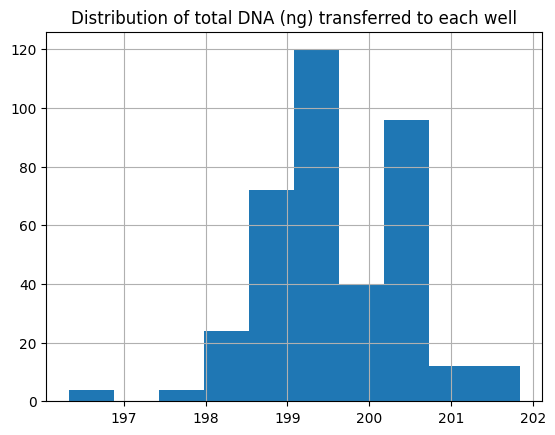

In [23]:
echo_ng_df = echo_df.groupby("Destination Well")["ng_transferred"].sum().reset_index().sort_values("ng_transferred", ascending=False)
print(echo_ng_df["ng_transferred"].describe())
echo_ng_df.hist()
plt.title("Distribution of total DNA (ng) transferred to each well")
echo_ng_df.head()

# Check number of destination wells

In [24]:
echo_df = output_association.copy()
print(echo_df["Destination Well"].nunique())
print(final_association["well_id"].nunique())

384
384


# Check transfer errors 

In [25]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Sample ID", "Destination Well", "Transfer Volume"]].groupby(["Destination Well", "Sample ID"]).sum().reset_index()
echo_df.sort_values(by=["Transfer Volume"], ascending=False,)

,Destination Well,Sample ID,Transfer Volume
1800,I23,puc19,1950
1682,I10,puc19,1950
827,D7,puc19,1950
2064,J8,puc19,1950
1100,F15,puc19,1950
...,...,...,...
813,D5,m166_GvpK_50fmol,25
771,D22,m166_GvpK_50fmol,25
775,D22,puc19,25
3302,P4,m166_GvpK_50fmol,25


In [26]:
# copy association file
df = final_association.copy()

# stock concentrations in nM
stock_dict = {mat.name: mat.concentration for mat in assoc_echo_calculator.material_dict.values() if mat}
stock_dict.pop('water', None)

# convert association concentrations to expected volumes
for idx, row in df.iterrows():
    for comp_idx in range(1, 10):  # loop over components 1–9
        comp_name_col = f"component_{comp_idx}"
        conc_col = f"concentration(nM).{comp_idx}"
        material = row[comp_name_col]
        
        if pd.notna(material) and material in stock_dict:
            df.loc[idx, conc_col] = (volume_final * row[conc_col]) / stock_dict[material]

# reshape into long format: Destination Well | Sample ID | Predicted Volume
comp_df_list = []
for comp_idx in range(1, 10):
    comp_df = df.loc[:, ["well_id", f"component_{comp_idx}", f"concentration(nM).{comp_idx}"]]
    comp_df = comp_df.rename(columns={
        "well_id": "Destination Well",
        f"component_{comp_idx}": "Sample ID",
        f"concentration(nM).{comp_idx}": "Predicted Volume"
    })
    comp_df_list.append(comp_df)

expected_df = pd.concat(comp_df_list, axis=0, ignore_index=True)
expected_df = expected_df[expected_df["Predicted Volume"] > 0]

# merge with echo_df (actual Echo picklist volumes)
comparison_df = expected_df.merge(
    echo_df, 
    on=["Destination Well", "Sample ID"], 
    how="left", 
    suffixes=('_expected', '_echo')
)

comparison_df["percent_error"] = (
    (comparison_df["Transfer Volume"] - comparison_df["Predicted Volume"]) 
    / comparison_df["Predicted Volume"] * 100
).abs()


In [27]:
comparison_df[comparison_df["percent_error"] > 10]

,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
3274,D22,puc19,31.165715,25,19.783646
3276,F2,puc19,31.165715,25,19.783646
3303,J10,puc19,31.165715,25,19.783646
3306,J16,puc19,27.897706,25,10.386896
3325,N6,puc19,31.165715,25,19.783646
3329,N14,puc19,27.897706,25,10.386896
3336,P4,puc19,27.897706,25,10.386896
3338,P8,puc19,27.897706,25,10.386896


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


372


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


372


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


...

372


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


376


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
3274,D22,puc19,31.165715,25,19.783646
3276,F2,puc19,31.165715,25,19.783646
3303,J10,puc19,31.165715,25,19.783646
3306,J16,puc19,27.897706,25,10.386896
3325,N6,puc19,31.165715,25,19.783646
3329,N14,puc19,27.897706,25,10.386896
3336,P4,puc19,27.897706,25,10.386896
3338,P8,puc19,27.897706,25,10.386896


384


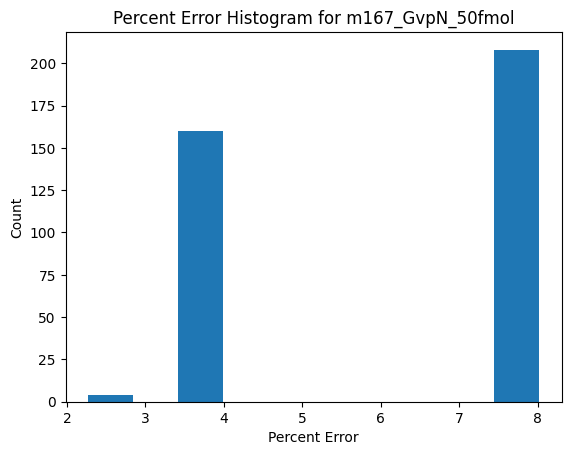

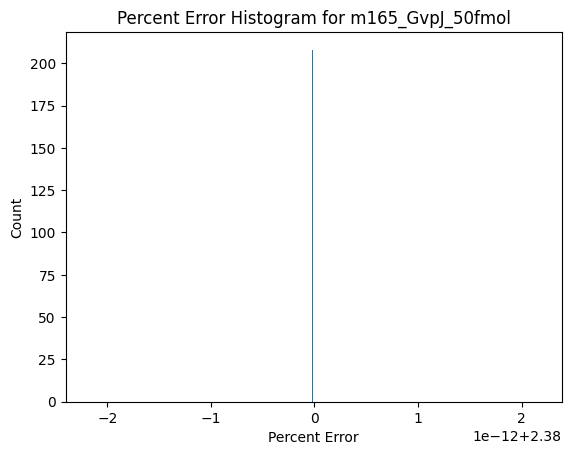

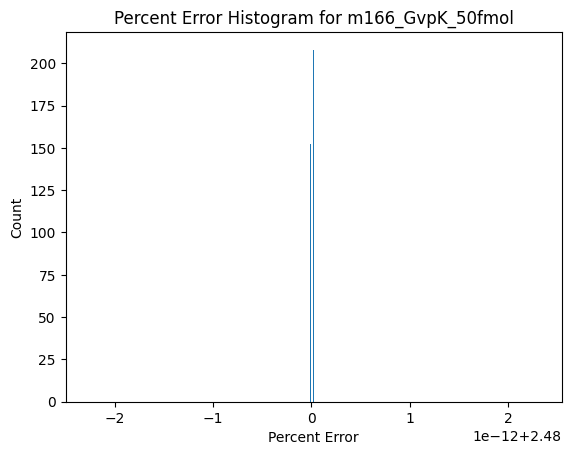

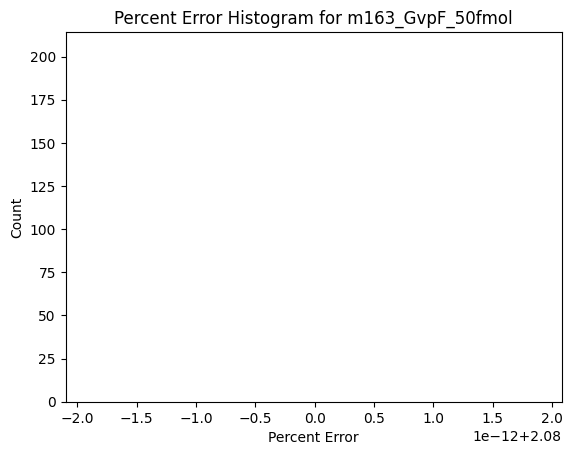

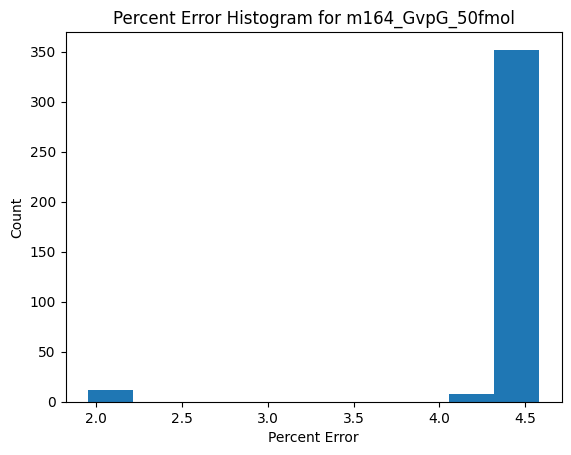

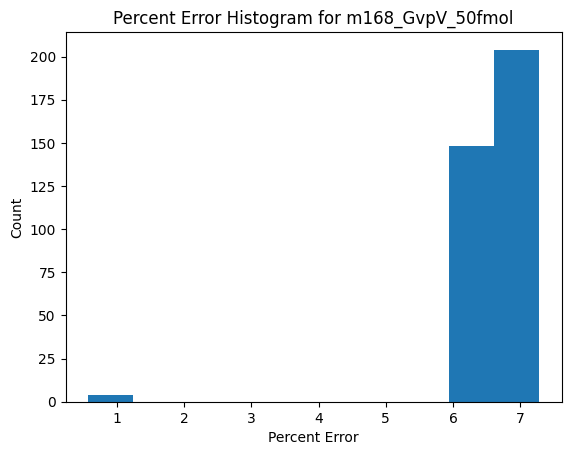

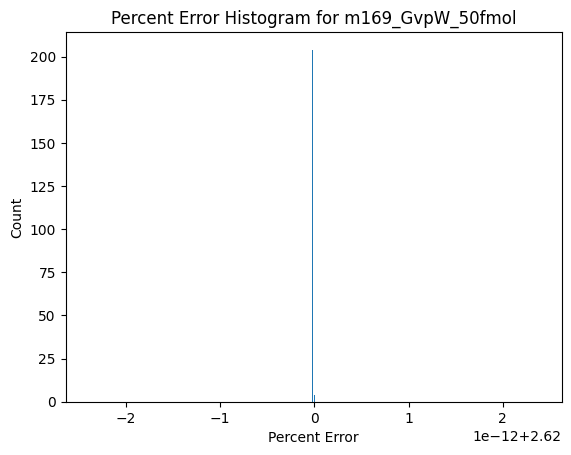

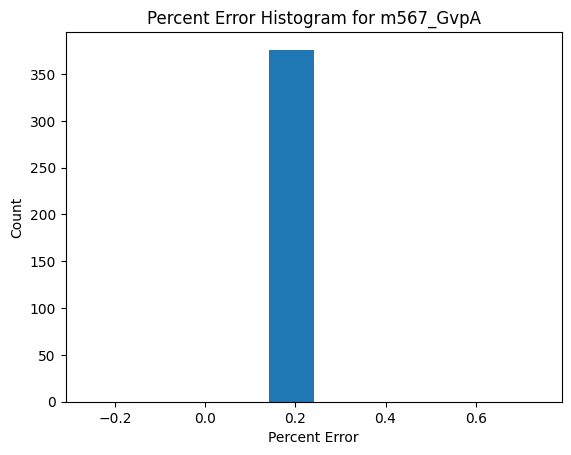

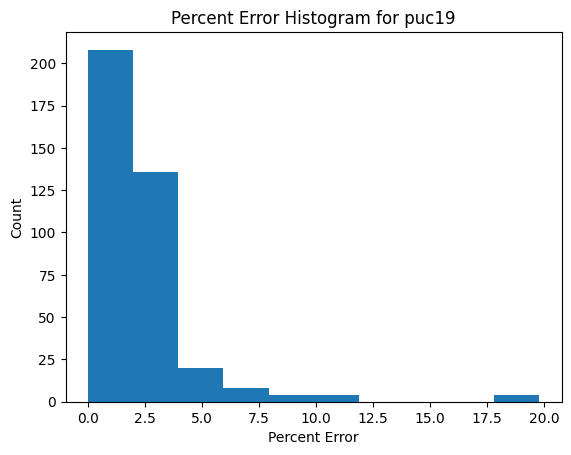

In [28]:
# loop over each unique material in the comparison table
for material in comparison_df["Sample ID"].unique():
    comp_comparison_df = comparison_df[comparison_df["Sample ID"] == material]

    # show rows where error > 10%
    if not comp_comparison_df.empty:
        display(comp_comparison_df[comp_comparison_df["percent_error"] > 10])
        print(len(comp_comparison_df))
        # histogram
        plt.figure()
        plt.hist(comp_comparison_df['percent_error'], bins=10)
        plt.title(f"Percent Error Histogram for {material}")
        plt.xlabel("Percent Error")
        plt.ylabel("Count")


In [29]:
echo_final_df = output_association.copy()
echo_final_df = echo_final_df[echo_final_df["Sample ID"] != "water"]
echo_final_df.to_csv(os.path.join(OUTPUT_DIR, "20251105_Arul_redo_50fmol_EchoInput_nowater.csv"), index=False)

In [30]:
# the dataframes should be identical (all 0s for this check)
(echo_final_df.reset_index(drop=True) != pd.read_csv(os.path.join(OUTPUT_DIR, "20251105_Arul_redo_50fmol_EchoInput_nowater.csv"))).sum()

Source Plate              0
Source Plate Type         0
Source Well               0
Sample ID                 0
Destination Plate Name    0
Destination Well          0
Transfer Volume           0
Sample Comment            0
dtype: int64

In [31]:
echo_df

,Destination Well,Sample ID,Transfer Volume
0,A1,m163_GvpF_50fmol,400
1,A1,m164_GvpG_50fmol,50
2,A1,m165_GvpJ_50fmol,50
3,A1,m166_GvpK_50fmol,50
4,A1,m167_GvpN_50fmol,50
...,...,...,...
3343,P9,m166_GvpK_50fmol,200
3344,P9,m168_GvpV_50fmol,175
3345,P9,m169_GvpW_50fmol,200
3346,P9,m567_GvpA,1125
